# Analyse du sondage pôle N MineSabords

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

In [34]:
df = pd.read_csv("data/poll.csv")
df.head()

,Horodateur,Tu es en...,Les raisons pour lesquelles tu prends part à un évènement entreprise...,"Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [1]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [2]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [3]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [4]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [5]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [6]","Les domaines d'activités qui t'intéressent le plus (1 = domaine préféré, 9 = moins intéressante) [7]",...,Un domaine n'apparaissant pas dans la question précédente ?,"Y a-t-il un type de fonction qui t'intéresse particulièrement dans une entreprise ?\n( par ex : R&D, recherche fondamentale, conseil, services et apps, etc... )",Les types d'évènements que tu préfères...,Qu'espères-tu obtenir d'un évènement entreprise,Qu'elles sont les principales choses que tu veux savoir sur une entreprise ?,Une entreprise particulière que tu aimerais rencontrer ?,"Es-tu intéressé.e par la création d'un forum ""entreprises publiques"" ?","Es-tu intéressé.e par la mise en place d'un forum sur le secteur ""énergie et environnement"" ?",Es-tu intéressé.e par la mise en place d'un forum Start-up,Une dernière chose ? :)
0,2026/03/13 8:26:22 PM UTC+2,1A IC,la renommée de l'entreprise;le domaine d'activ...,Énergie et Environnement;Aéronautique;Économie...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,les amphis entreprises;les études de cas,NaN,NaN,NaN,Why not,oui,oui,NaN
1,2026/03/16 6:00:17 PM UTC+2,1A IC,le domaine d'activité de l'entreprise,Environnement,Énergie,Robotique et Automatisation,Économie et Finance,Transports,"Numérique, Informatique et IA",Santé et Biotechnologies,...,NaN,Recherche ou R&D,les amphis entreprises;les tables rondes;les v...,"Rencontrer des travailleurs, découvrir des ent...",Variété d'emplois,"Des services publics, CNRS, EDF, SNCF...",oui,oui,non,NaN
2,2026/03/16 6:21:59 PM UTC+2,1A IC,la présence d'un repas lors de l'évènement,Aéronautique,Mode et Luxe,Santé et Biotechnologies,"Numérique, Informatique et IA",Transports,Robotique et Automatisation,Environnement,...,Automobile,R&D,les amphis entreprises;les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN
3,2026/03/16 7:36:49 PM UTC+2,1A IC,la recherche d'un stage,Énergie,Environnement,Robotique et Automatisation,"Numérique, Informatique et IA",Aéronautique,Mode et Luxe,Économie et Finance,...,NaN,NaN,les études de cas,NaN,NaN,NaN,non,Non,oui,NaN
4,2026/03/17 10:58:03 AM UTC+2,1A IC,le domaine d'activité de l'entreprise,Aéronautique,Énergie,Santé et Biotechnologies,"Numérique, Informatique et IA",Robotique et Automatisation,Transports,Environnement,...,NaN,r et d,les tables rondes,NaN,NaN,NaN,oui,oui,oui,NaN


In [35]:
print("Nombre de réponses :", len(df))

Nombre de réponses : 112


### Répartition des votant.e.s par année d'étude

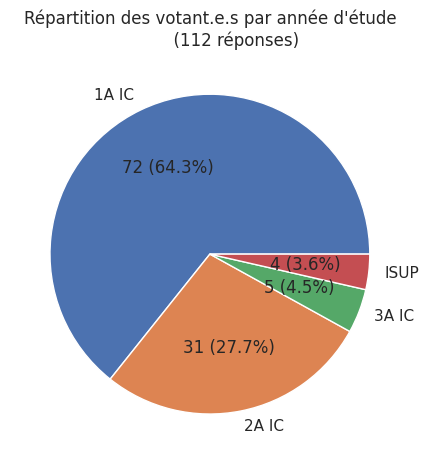

In [36]:
prom = df["Tu es en..."].value_counts()
total = prom.sum()

plt.pie(prom, labels=prom.index,
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Répartition des votant.e.s par année d'étude
          ({len(df)} réponses)""")

plt.tight_layout()
plt.savefig("plots/prom.svg", bbox_inches="tight")
plt.savefig("plots/prom.pdf", bbox_inches="tight")
plt.show()

### Les raisons poussant à aller à un événement

In [37]:
reasons_data = df["Les raisons pour lesquelles tu prends part à un évènement entreprise..."].value_counts()

# each reason is separated by a semicolon
# so we need to split them and count them
reasons = {}
type_of_meal = {}

not_interested = ["J'y vais pas...",
                  "Je n'y ai jamais pris part",
                  "En vrai j’y participe pas"]

cocktail_lunch = ["La présence d'un repas lors de l'évènement",
                  "La présence d'un cocktail lors de l'évènement"]

combined_label = "Présence d'un repas ou cocktail lors de l'évènement"
cocktail_count = 0
meal_count = 0

for reason_list in reasons_data.index:
    count = reasons_data[reason_list]

    meal_already_counted = False

    for reason in reason_list.split(";"):
        reason = reason.strip().lower().capitalize()

        if reason in not_interested:
            reason = "Jamais pris part à un événement"

        if reason in cocktail_lunch :
            if reason == "La présence d'un cocktail lors de l'évènement":
                cocktail_count += count
                
            else:
                meal_count += count

            if not meal_already_counted :
                reason = combined_label
                meal_already_counted = True

            else:
                continue

        if reason not in reasons:
            reasons[reason] = 0

        reasons[reason] += count

print(reasons)
print(f"{combined_label} -> cocktail: {cocktail_count}, repas: {meal_count}")

{"La renommée de l'entreprise": 54, "Le domaine d'activité de l'entreprise": 93, "La recherche d'un stage": 48, "Présence d'un repas ou cocktail lors de l'évènement": 75, "La politique éthique de l'entreprise": 45, "Le fait de ne pas connaître l'entreprise présentée": 30, 'Jamais pris part à un événement': 3, "Donner de l'argent au bde": 1}
Présence d'un repas ou cocktail lors de l'évènement -> cocktail: 38, repas: 75


attention, certains ont mis les 2, faire un second graphique pour voir la répartition

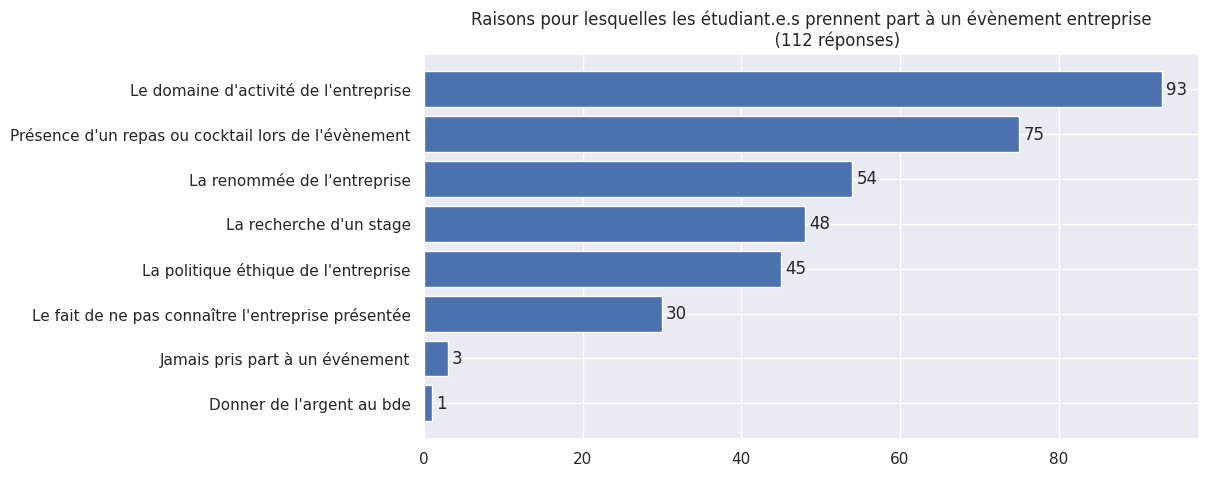

In [42]:
# plot the reasons in a bar chart, sorted by value
reasons = dict(sorted(reasons.items(), key=lambda item: item[1]))

labels = list(reasons.keys())

plt.figure(figsize=(10, 5))

bars = plt.barh(labels, list(reasons.values()))
plt.bar_label(bars, padding=3)

"""plt.barh(combined_label, meal_count, label="Repas")
plt.barh(combined_label, cocktail_count, left=meal_count, label="Cocktail")
plt.legend()"""

plt.title(f"""Raisons pour lesquelles les étudiant.e.s prennent part à un évènement entreprise
          ({len(df)} réponses)""")

plt.savefig("plots/reasons.svg", bbox_inches="tight")
plt.savefig("plots/reasons.pdf", bbox_inches="tight")
plt.show()

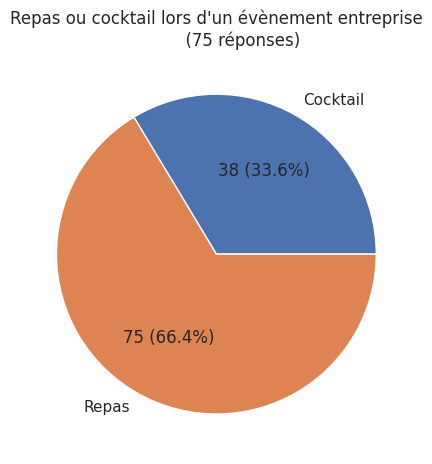

In [43]:
total = cocktail_count + meal_count
amount_voters = reasons[combined_label]

plt.pie([cocktail_count, meal_count], labels=["Cocktail", "Repas"],
        autopct=lambda pct: f"{int(round(pct * total / 100.0))} ({pct:.1f}%)")

plt.title(f"""Repas ou cocktail lors d'un évènement entreprise
          ({amount_voters} réponses)""")

plt.tight_layout()
plt.savefig("plots/meal_cocktail.svg", bbox_inches="tight")
plt.savefig("plots/meal_cocktail.pdf", bbox_inches="tight")
plt.show()